# Arb Model: Would Restricting Training to Super Two / Arb-1 Help?

`models/arb/` (see `3_arb_deterministic_model.ipynb`) trains its per-role regression on the
**full** cleaned arb dataset (Super Two through Arb-3 together) but only **serves** Super
Two/Arb-1 predictions — Arb-2/Arb-3 requests raise `UnsupportedSegmentError`. That was a
deliberate choice to match what the original analysis validated (one model, evaluated by band
afterward), but it leaves an open question: since we only ever *serve* Super Two/Arb-1, would
the model actually do better on that population if it were *trained* on nothing else?

Two competing intuitions:
- **More data helps.** Arb-2/Arb-3 rows still carry real WAR/service-time/pay signal; more
  training rows generally stabilizes an OLS fit, even for a sub-population.
- **Relevance beats volume.** If the WAR→pay relationship genuinely shifts across bands (which
  the original notebook's walk-year findings suggest it does), training on higher bands could
  bias the fitted slope away from what's actually true for Super Two/Arb-1 players specifically.

This notebook tests it empirically with a walk-forward comparison, reusing the exact shipped
cleaning/feature pipeline from `models/arb/features.py` (not a hand-copied reimplementation) so
the comparison is against what's actually running in production, not an approximation of it.
This is exploratory analysis, not part of the production pipeline.

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from models.arb.config import MIN_TRAINING_ROWS, ROLE_FEATURE_SPECS, SUPPORTED_ARB_BANDS
from models.arb.features import arb_band, build_training_frame

pd.set_option("display.max_columns", None)
plt.rcParams["figure.dpi"] = 110

## 1. Load the shipped cleaned/reclassified arb dataset

`build_training_frame()` is the exact function `models/arb/model.py` calls to fit coefficients
— same filters (duration==1, broken stats-join rows excluded, Ohtani excluded), same
workload-based SP/RP reclassification, same normalized `service_time`. We add `arb_band` (via
the same `arb_band()` the production model uses for its serving gate) and a dollar-scale `aav`
column for readable residuals.

In [2]:
frame = build_training_frame()
frame["arb_band"] = frame["service_time"].apply(arb_band)
frame["aav"] = np.exp(frame["log_aav"])

print(f"total cleaned arb rows: {len(frame)} (contract years {frame['contract_year'].min()}-{frame['contract_year'].max()})")
print()
print(frame.groupby(["role", "arb_band"]).size().unstack(fill_value=0))
print()
served = frame["arb_band"].isin(SUPPORTED_ARB_BANDS)
print(f"Super Two/Arb-1 share of the full dataset: {served.mean()*100:.1f}% ({served.sum()} of {len(frame)} rows)")

total cleaned arb rows: 2765 (contract years 2011-2026)

arb_band  Arb-1  Arb-2  Arb-3  Super Two
role                                    
RP          430    294    174        114
SP          223    169    105         71
batter      493    328    215        147

Super Two/Arb-1 share of the full dataset: 53.5% (1478 of 2765 rows)


## 2. Walk-forward comparison: two training variants, one shared test population

Same walk-forward mechanics as `3_arb_deterministic_model.ipynb` (fit on strictly-prior years,
predict the target year, pool across years) and the same `MIN_TRAINING_ROWS` floor `models/arb/`
actually enforces. The only difference between variants is what's in the *training* set:

- **Full-band training** (current production behavior): train on all bands for the role.
- **Restricted training**: train on Super Two/Arb-1 rows for the role only.

The **test set is identical for both** — Super Two/Arb-1 rows only — since that's the only
population `models/arb/` ever actually serves. This isolates the effect of training scope from
any change in what's being evaluated.

In [3]:
def raw_ols_fit(data, y_col, x_cols):
    sub = data[[y_col] + x_cols].dropna()
    n = len(sub)
    X = np.column_stack([sub[c].values for c in x_cols] + [np.ones(n)])
    y = sub[y_col].values
    coefs, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coefs


def walk_forward(data, specs, restrict_training, start_year=2017, end_year=2027):
    """restrict_training=True limits the TRAINING set to Super Two/Arb-1; the test set
    (Super Two/Arb-1 only) is identical either way."""
    records = []
    skipped = []
    for test_year in range(start_year, end_year):
        train_full = data[data["contract_year"] < test_year]
        test = data[(data["contract_year"] == test_year) & data["arb_band"].isin(SUPPORTED_ARB_BANDS)]
        for role, xcols in specs.items():
            tr = train_full[train_full["role"] == role]
            if restrict_training:
                tr = tr[tr["arb_band"].isin(SUPPORTED_ARB_BANDS)]
            te = test[test["role"] == role]
            sub_tr = tr[["log_aav"] + xcols].dropna()
            if len(sub_tr) < MIN_TRAINING_ROWS or te.empty:
                skipped.append((test_year, role))
                continue
            coefs = raw_ols_fit(tr, "log_aav", xcols)
            cols = list(dict.fromkeys(["player_id", "contract_year", "aav", "arb_band"] + xcols))
            sub_te = te[cols].dropna(subset=xcols + ["aav"]).copy()
            if sub_te.empty:
                continue
            X = np.column_stack([sub_te[c].values for c in xcols] + [np.ones(len(sub_te))])
            sub_te["role"] = role
            sub_te["predicted"] = np.exp(X @ coefs)
            sub_te["resid"] = sub_te["aav"] - sub_te["predicted"]
            sub_te["train_n"] = len(sub_tr)
            records.append(sub_te)
    out = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
    return out, skipped

In [4]:
res_full, skipped_full = walk_forward(frame, ROLE_FEATURE_SPECS, restrict_training=False)
res_restricted, skipped_restricted = walk_forward(frame, ROLE_FEATURE_SPECS, restrict_training=True)


def summarize(res, label):
    mae_by_role = res.groupby("role")["resid"].apply(lambda x: x.abs().mean()).round(3)
    hit1_by_role = res.groupby("role")["resid"].apply(lambda x: (x.abs() <= 1.0).mean() * 100).round(1)
    print(f"{label}: n={len(res)}")
    print(f"  MAE by role      -> {mae_by_role.to_dict()}")
    print(f"  within $1M % by role -> {hit1_by_role.to_dict()}")
    print(f"  pooled MAE = {res['resid'].abs().mean():.3f}")


summarize(res_full, "Full-band training (current production)")
print()
summarize(res_restricted, "Restricted (Super Two/Arb-1 only) training")
print()
print(f"skipped role-year windows (insufficient training rows): full={len(skipped_full)}, restricted={len(skipped_restricted)}")

Full-band training (current production): n=823
  MAE by role      -> {'RP': 0.447, 'SP': 0.664, 'batter': 0.72}
  within $1M % by role -> {'RP': 89.3, 'SP': 77.1, 'batter': 81.5}
  pooled MAE = 0.617

Restricted (Super Two/Arb-1 only) training: n=823
  MAE by role      -> {'RP': 0.442, 'SP': 0.67, 'batter': 0.732}
  within $1M % by role -> {'RP': 90.0, 'SP': 76.4, 'batter': 81.0}
  pooled MAE = 0.622

skipped role-year windows (insufficient training rows): full=0, restricted=0


**Headline: essentially a wash pooled** — restricting training to Super Two/Arb-1 doesn't move
the pooled MAE meaningfully ($0.617M full-band vs. $0.622M restricted), and no role-year window
under either variant ever falls short of `MIN_TRAINING_ROWS` — restricting training roughly
halves the available rows (see Section 4) but never starves the fit. The real story is in the
per-role, per-band breakdown below, where the two variants diverge in opposite directions.

## 3. Breaking it down: role × band

The pooled wash hides a real, opposite-direction split for batters specifically.

In [5]:
def band_table(res, label):
    rows = []
    for role in ("batter", "SP", "RP"):
        for band in ("Super Two", "Arb-1"):
            sub = res[(res["role"] == role) & (res["arb_band"] == band)]
            if sub.empty:
                continue
            ss_res = (sub["resid"] ** 2).sum()
            ss_tot = ((sub["aav"] - sub["aav"].mean()) ** 2).sum()
            r2 = 1 - ss_res / ss_tot if ss_tot > 0 else float("nan")
            rows.append(
                dict(
                    variant=label,
                    role=role,
                    band=band,
                    n=len(sub),
                    MAE_dollarsM=round(sub["resid"].abs().mean(), 3),
                    R2=round(r2, 3),
                    within_1M_pct=round((sub["resid"].abs() <= 1.0).mean() * 100, 1),
                )
            )
    return pd.DataFrame(rows)


comparison = pd.concat(
    [band_table(res_full, "full"), band_table(res_restricted, "restricted")], ignore_index=True
)
comparison.sort_values(["role", "band", "variant"]).reset_index(drop=True)

,variant,role,band,n,MAE_dollarsM,R2,within_1M_pct
0,full,RP,Arb-1,225,0.483,0.375,88.0
1,restricted,RP,Arb-1,225,0.481,0.322,88.9
2,full,RP,Super Two,55,0.299,0.481,94.5
3,restricted,RP,Super Two,55,0.285,0.540,94.5
4,full,SP,Arb-1,109,0.716,0.680,73.4
5,restricted,SP,Arb-1,109,0.723,0.671,72.5
6,full,SP,Super Two,35,0.504,0.461,88.6
7,restricted,SP,Super Two,35,0.505,0.455,88.6
8,full,batter,Arb-1,306,0.723,0.620,81.4
9,restricted,batter,Arb-1,306,0.751,0.586,80.4


For **batters**, restriction cuts both ways: Arb-1 gets *worse* (MAE $0.723M → $0.751M, R²
0.620 → 0.586) while Super Two gets *better* (MAE $0.709M → $0.668M, R² 0.546 → 0.588). For
**RP**, restriction helps slightly in both bands. For **SP**, it's a negligible wash in both
bands. There's no single answer across roles — batters specifically show a real relevance-vs-volume
tradeoff between their two served bands, while pitchers don't show much sensitivity either way.

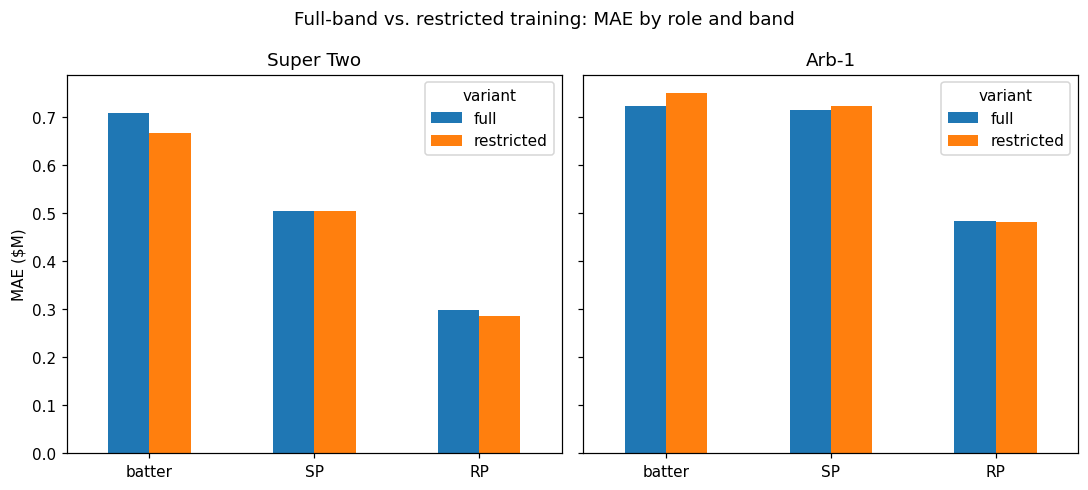

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
for ax, band in zip(axes, ("Super Two", "Arb-1")):
    sub = comparison[comparison["band"] == band].pivot(index="role", columns="variant", values="MAE_dollarsM")
    sub = sub.reindex(["batter", "SP", "RP"])
    sub[["full", "restricted"]].plot.bar(ax=ax, rot=0)
    ax.set_title(band)
    ax.set_ylabel("MAE ($M)")
    ax.set_xlabel("")
fig.suptitle("Full-band vs. restricted training: MAE by role and band")
fig.tight_layout()

## 4. Does restriction ever starve the fit of data?

Restricting training roughly halves the row count available at any given walk-forward cutoff,
but the underlying dataset is large enough that this never approaches the `MIN_TRAINING_ROWS`
floor, even in the earliest walk-forward years.

In [7]:
rows = []
for test_year in (2017, 2018, 2022, 2026):
    for role in ("batter", "SP", "RP"):
        tr_full = frame[(frame["contract_year"] < test_year) & (frame["role"] == role)]
        tr_restricted = tr_full[tr_full["arb_band"].isin(SUPPORTED_ARB_BANDS)]
        rows.append(dict(test_year=test_year, role=role, train_n_full=len(tr_full), train_n_restricted=len(tr_restricted)))
pd.DataFrame(rows)

,test_year,role,train_n_full,train_n_restricted
0,2017,batter,357,201
1,2017,SP,151,77
2,2017,RP,291,170
3,2018,batter,429,237
4,2018,SP,185,96
5,2018,RP,363,211
6,2022,batter,745,405
7,2022,SP,352,183
8,2022,RP,628,351
9,2026,batter,1090,587


Even the smallest restricted-training case (SP, 2017) has well over 100 rows — an order of
magnitude above the `MIN_TRAINING_ROWS=20` floor. Sample size is not the bottleneck for this
particular decision; whichever way it goes, it's a relevance question, not a data-availability one.

## Conclusion

**Recommendation: keep training on the full arb dataset (current `models/arb/` behavior);
don't switch to Super Two/Arb-1-only training.**

- Pooled, the two approaches are a wash ($0.617M vs. $0.622M MAE) — there's no clear overall
  win from restricting.
- The one place restriction visibly *helps* (batter Super Two) is offset by where it visibly
  *hurts* (batter Arb-1) — within the very population this scoping decision is about, so it
  isn't a clean win even at the role level.
- It's not a data-availability question — even restricted, every role-year window has more
  than enough rows to fit; the tradeoff is purely about whether Arb-2/Arb-3 rows are relevant
  "signal" or "noise" for Super Two/Arb-1 pay, and the answer here is genuinely mixed rather
  than a clear one-directional finding of "noise."
- Given no clear win and one clear regression (batter Arb-1, currently the single largest
  served role × band bucket at $n=306$), restricting training would trade a small, uncertain
  gain in one bucket for a real loss in a bigger one. Not worth the change.

If batter Arb-1 vs. Super Two accuracy specifically becomes a priority later, a role-and-band-aware
*feature* (e.g. letting the interaction term vary by band directly, rather than changing what
rows get trained on) is a more promising direction than this blunter training-scope lever.